# **LASSO regression - TEST**

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Lasso

# Ignore warnings
import warnings

warnings.filterwarnings("ignore")


In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

In [3]:
TrainingDataFrame["Time_flow"] = np.arange(1, len(TrainingDataFrame)+1)
historic_columns.append("Time_flow")

# **LASSO regression**

In [4]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 3 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Lasso(alpha=4.579999999999998, max_iter=3000)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))

        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
        
    performance_tracker[ticker] = MAPEs.copy()
    performance_simple[ticker] = AccuracyToSimple.copy()
    model_dominance[ticker] = dominance_dates.copy()


In [5]:
np.mean([np.mean(i) for i in performance_simple.values()])

np.float64(0.38826923076923076)

In [6]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [7]:
np.mean(list(mean_performances.values()))

np.float64(2.240073329696101)

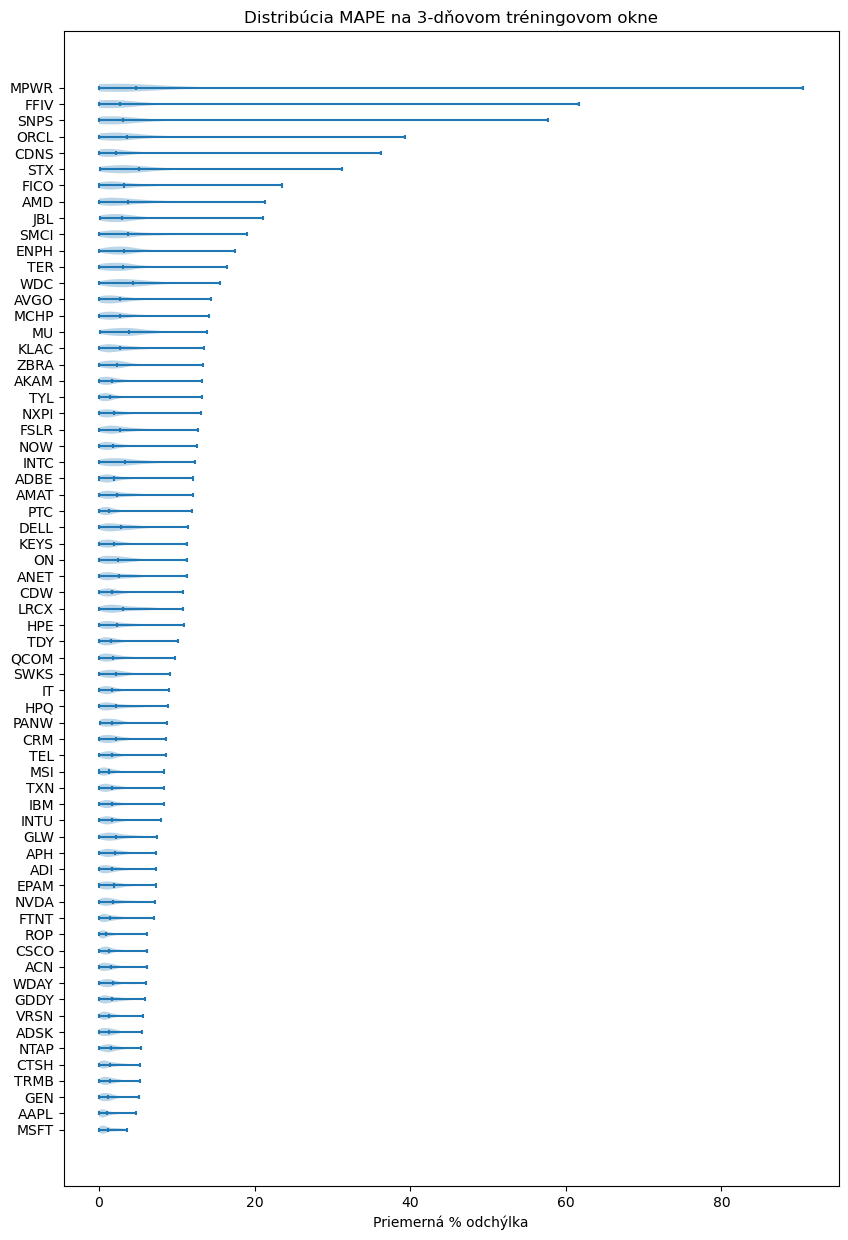

In [8]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [9]:
mean_performances

{'ROP': np.float64(0.9536931583258973),
 'AAPL': np.float64(1.0333586590298744),
 'MSFT': np.float64(1.1891489170951364),
 'GEN': np.float64(1.2267912854736251),
 'MSI': np.float64(1.2350871602623665),
 'CSCO': np.float64(1.2583762447771552),
 'VRSN': np.float64(1.2600679225033091),
 'ADSK': np.float64(1.3215196776567406),
 'PTC': np.float64(1.3280803404485204),
 'CTSH': np.float64(1.3909731512786982),
 'FTNT': np.float64(1.3962283759653116),
 'TYL': np.float64(1.444216708124031),
 'TRMB': np.float64(1.4631541102701326),
 'ACN': np.float64(1.4982750747826468),
 'TDY': np.float64(1.512205299701098),
 'NTAP': np.float64(1.514112652837803),
 'TXN': np.float64(1.6229496630036018),
 'TEL': np.float64(1.632966320124514),
 'GDDY': np.float64(1.6449244776784533),
 'IT': np.float64(1.6460669185364636),
 'IBM': np.float64(1.6623785280458219),
 'ADI': np.float64(1.7122713868703485),
 'CDW': np.float64(1.718474179536034),
 'PANW': np.float64(1.7281277304163243),
 'AKAM': np.float64(1.7303168196915

# **LASSO Stock-wise optimality**

In [15]:
optimal_parameters = {}
with open("LASSO/LASSO_StockWise.txt") as file:
    for i in file.readlines():
        data = i.split()
        optimal_parameters[data[0]] = float(data[1])

In [16]:
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2025-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Lasso(alpha=optimal_parameters[ticker])

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

ACN 0.16521685408167178
ACN 2.58320587056589
ACN 0.9153868639686338
ACN 4.239878480733648
ACN 2.7714510928359766
ACN 0.7336513735613803
ACN 0.11049882639589445
ACN 0.037703799868783874
ACN 1.2803699369450536
ACN 2.326550846120913
ACN 2.2590704539522997
ACN 1.037531391338972
ACN 4.218889841094286
ACN 2.3556820884268013
ACN 4.070872201782136
ACN 2.2840059619462836
ACN 3.453763137982106
ACN 0.831621288107048
ACN 1.280035898290194
ACN 4.76427847415517
ACN 2.4204917340130665
ACN 1.9124738679044269
ACN 0.1049877418285532
ACN 0.595170039933766
ACN 1.5818066815365825
ACN 1.0676086610549635
ACN 0.25275870335616224
ACN 0.0719698065117262
ACN 0.6732010118805308
ACN 2.4639803993970864
ACN 0.05952171314167017
ACN 2.4757629046907974
ACN 0.2583799320593958
ACN 0.038848920145089214
ACN 0.9513121577372302
ACN 1.2077641383485005
ACN 1.0986827037313616
ACN 0.03772071370135425
ACN 1.714457685139351
ACN 2.1500015258789062
ACN 1.0152240408334001
ACN 0.4630629756014624
ACN 4.387534881342545
ACN 0.07798818480

In [17]:
means_prevalences = [np.mean(i) for i in performance_simple.values()]
np.mean(means_prevalences)
# 0.444066099148723

np.float64(0.370983446932814)

In [18]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [19]:
np.mean(list(mean_performances.values()))

np.float64(2.3109030115796902)

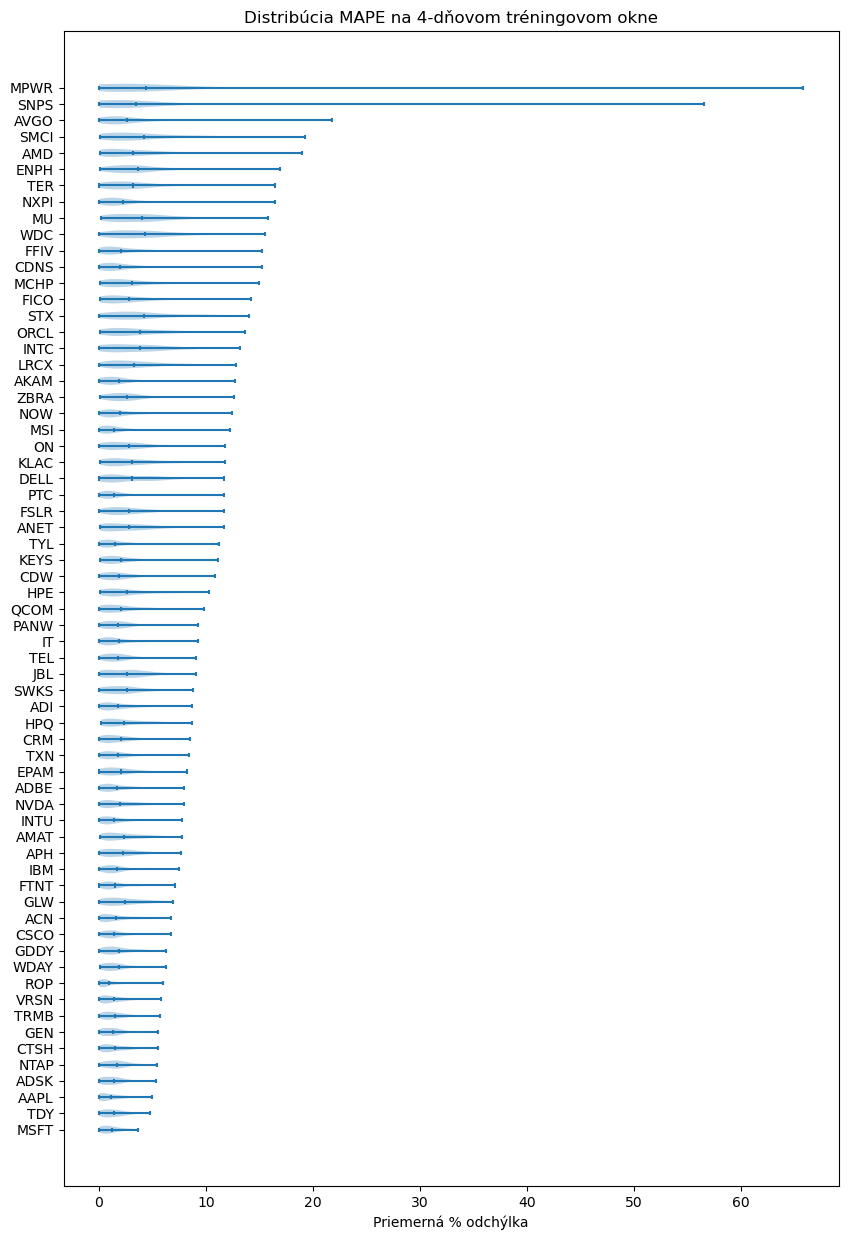

In [20]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()